## Importy

In [6]:
import numpy as np #import knihovnu numpy pro práci s poli a matematickými funkcemi
import matplotlib.pyplot as plt #import knihovnu matplotlib pro vykreslování grafů
import funkce as fun #import funkce.py, kde jsou definovány moje funkce

## Vykreslení trajektorie

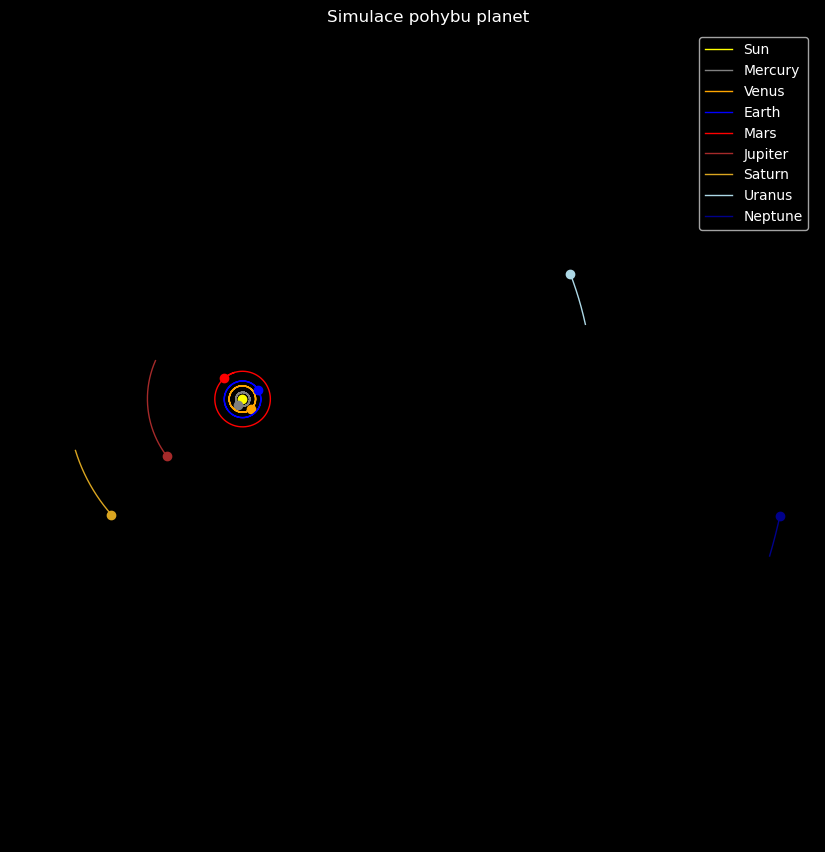

In [7]:
barvy = {
    "Sun": "yellow",
    "Mercury": "gray",
    "Venus": "orange",
    "Earth": "blue",
    "Mars": "red",
    "Jupiter": "brown",
    "Saturn": "goldenrod",
    "Uranus": "lightblue",
    "Neptune": "darkblue"
} 

planety = fun.soubor_planet()
historie = fun.simluj_planety(planety, 365*2, 60*60*24)

plt.figure(figsize=(10, 10), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

for nazev, p in planety.items():
    body = np.array(historie[nazev])
    barva = barvy.get(nazev)
    plt.plot(body[:, 0], body[:, 1], color=barva, linewidth=1, label=nazev)
    plt.plot(body[-1, 0], body[-1, 1], "o", color=barva, markersize=6)

plt.legend(facecolor="black", labelcolor="white")
plt.title("Simulace pohybu planet", color="white")
plt.axis("equal")
plt.show()

## Pozice planety po určitém čase

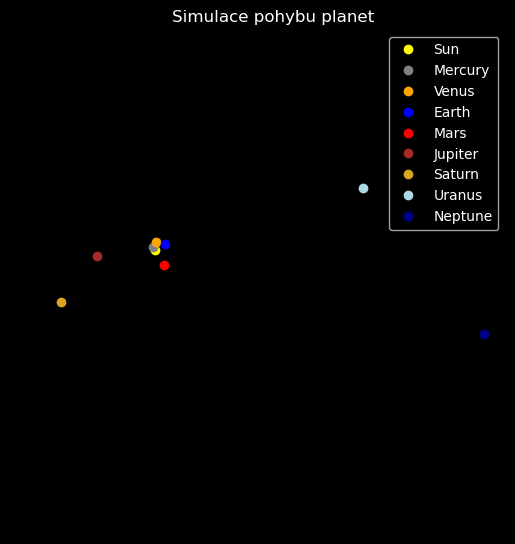

In [8]:
planety = fun.soubor_planet()
historie = fun.simluj_planety(planety, 365, 60*60*24)

plt.figure(figsize=(6, 6), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

for nazev, p in planety.items():
    body = np.array(historie[nazev])
    barva = barvy.get(nazev)
    plt.plot(body[-1, 0], body[-1, 1], "o", color=barva, markersize=6,label=nazev)

plt.legend(facecolor="black", labelcolor="white")
plt.title("Simulace pohybu planet", color="white")
plt.axis("equal")
plt.show()

## Funkce pro generování náhodných počátečních hodnot

In [9]:
nahodne_planety = fun.generuj_nahodny_scenar(3)
for nazev, p in nahodne_planety.items():
    print(f"{nazev}: hmotnost={p['mass']:.2e}")
    print(f"{nazev}: pozice={p['position']}")
    print(f"{nazev}: rychlost={p['velocity']}\n")

Planeta_1: hmotnost=4.24e+29
Planeta_1: pozice=[ 0.62748748 -0.39197759]
Planeta_1: rychlost=[ -98.71331021 1062.46897414]

Planeta_2: hmotnost=9.53e+29
Planeta_2: pozice=[-0.72848968 -1.49980716]
Planeta_2: rychlost=[ 2751.82558452 -1859.65149653]

Planeta_3: hmotnost=2.60e+28
Planeta_3: pozice=[-1.66173449  0.54076625]
Planeta_3: rychlost=[1328.55983869  782.58856729]



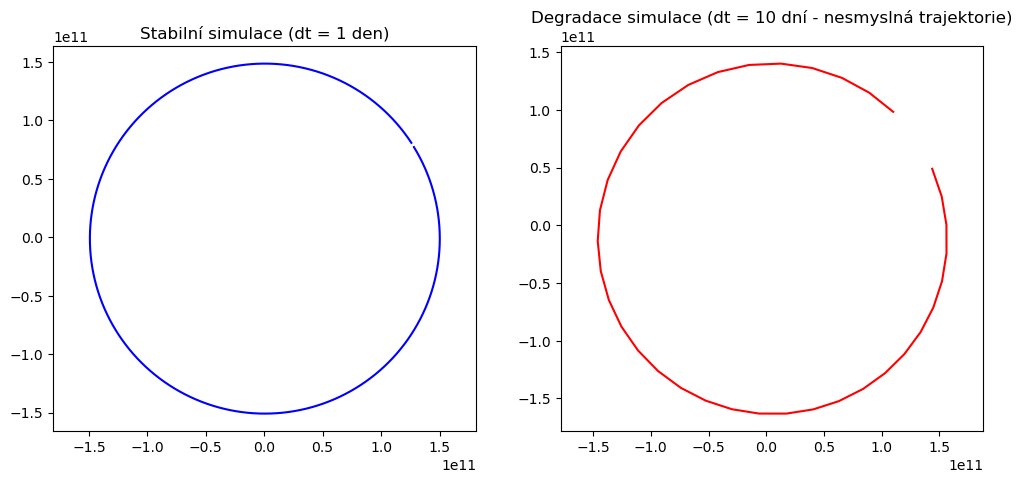

In [10]:
KROK_STABILNI = 60 * 60 * 24       # 1 den
KROK_NESTABILNI = 60 * 60 * 24 * 10  # 10 dní

historie_stabilni = fun.simluj_planety(planety, 365, KROK_STABILNI)
historie_nestabilni = fun.simluj_planety(planety, 36, KROK_NESTABILNI)

# Vykreslení stabilní vs nestabilní trajektorie (např. Země)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
zeme_stab = np.array(historie_stabilni["Earth"])
plt.plot(zeme_stab[:, 0], zeme_stab[:, 1], color="blue")
plt.title("Stabilní simulace (dt = 1 den)")
plt.axis("equal")

plt.subplot(1, 2, 2)
zeme_nestab = np.array(historie_nestabilni["Earth"])
plt.plot(zeme_nestab[:, 0], zeme_nestab[:, 1], color="red")
plt.title("Degradace simulace (dt = 10 dní - nesmyslná trajektorie)")
plt.axis("equal")
plt.show()